## Phase 0 - Accessing Semantic Scholar and Handling IPs/API keys 

### Imports

In [109]:
import os
import sys
from dotenv import load_dotenv
import requests
from semanticscholar import AsyncSemanticScholar
import asyncio
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pymed import PubMed
import time
import numpy as np

### Checking for API Key or IP Access

In [46]:
nest_asyncio.apply()

load_dotenv(override=True)


# 1. GETTING USER API KEY. DEFAULTS AND CHECKS IP IF KEY IS NOT FOUND
api_key = os.getenv("SEMANTIC_SCHOLAR_API_KEY")
is_key_good = False

print("Searching for User's API Key...")

if api_key is None or api_key == "your_key_here" or api_key.strip() == "":
    print(f"User provided this: '{api_key}' as an API Key. Defaulting to lower limit access...")
    print("Checking IP status...")

    #CHECKING IF IP IS BLOCKED OR NOT
    url = "https://api.semanticscholar.org/graph/v1/paper/search"
    query_params = {"query": "test", "limit": 1}
    
    print("Pinging Semantic Scholar...")
    response = requests.get(url, params=query_params)

    if response.status_code == 200:
        print("Your IP is clear to access Semantic Scholar. Ready to start!")
    elif response.status_code == 429:
        sys.exit("Your IP is currently blocked from using Semantic Scholar")

else:
    print("API Key found! Going to Semantic Scholar...")
    is_key_good = True

Searching for User's API Key...
API Key found! Going to Semantic Scholar...


### Validating Semantic Scholar Key

In [4]:

# 2. CONNECTING TO SEMANTIC SCHOLAR
sch = None
if is_key_good:
    sch = AsyncSemanticScholar(api_key=api_key)
else:
    sch = AsyncSemanticScholar()


# 3. VALIDATING THE API KEY
try:
    testing_api_key_works = await sch.get_paper("8ceb75144ecb846bf463e7565e6a18998ae29d1a", fields=["title"])
    # The id for Protein measurement with the Folin phenol reagent. That is the most cited paper on Semantic Scholar.
    print("Your API Key has been approved!")

except Exception as e:
    print(f"API Key Error: {e}")
    sys.exit("Your API key was not authorized for usage by Semantic Scholar")



Your API Key has been approved!


## Phase 1 - Method 1.1

### Setting Queries and Filtering Terms

In [139]:
chills_papers = []
target_num = 500

topic_terms = [
    "frisson",
    "psychogenic",
    "aesthetic chill",
    "musical thrill",
    "music thrill",
    "musical chill",
    "music chill",
    "music-induced",
    "music induced",
    "music-evoke",
    "music evoke",
    "induced pleasure",
    "evoked emotion",
    "piloerection",
    "goosebump",
    "gooseflesh",
    "chills response",
    "tingl",
    "spine",
    "peak experien"
]

neuro_terms = [
    "neuro",
    #brain
    "brain scan",
    "nerv",
    "fmri",
    "eeg",
    #"scan",
    "dopamine",
    #reward
    "reward path",
    "reward circuit",
    "reward system",
    "cortex",
    "striatum",
    "autonom",
    "recept",
    "amygdala",
    "insula",
    "hemo",
    #"physiologic",
    "electroderma",
    "skin conduct",
    "galv",
    "gsr",
    "hrv",
    "nucl",
    "accumben",
    "ventr",
    "tegment",
    "vta",
    "limbic",
    "thalam",
    "sympathetic",
    "endogen",
    "opioid",
    "endorphin",
    "naltrexone",
    "pupil",
    "dilat",
    "respirat",
    "fnir"
]

search_queries = [
    "music frisson",
    "music chill",
    "music thrill",
    "aesthetic chill",
    "music goosebump",
    "music pleasure",
    "sound bump reaction",
    "psycho shiver",
    "music piloerect",
]

time_periods = [
    "1980-1984",
    "1985-1989",
    "1990-1994",
    "1995-1999",
    "2000-2004",
    "2005-2009",
    "2010-2014",
    "2015-2019",
    "2020-2026"
]



### Requesting Papers from Semantic Scholar

In [27]:
print("Beginning Extraction for Major Phenomena: Musical Frisson...")

results = []
ids = set()
max_retries = 5

for t in time_periods:
    for sq in search_queries:
        isSuccessful = False
        retries = 0

        while not isSuccessful and retries < max_retries: 
            try:
                temp_results = await sch.search_paper(
                    sq,
                    year=t,
                    limit=100,
                    fields=[
                        "title",
                        "authors",
                        "year",
                        "citationCount",
                        "abstract"
                    ]
                )

                print(f"Searching {t} for '{sq}'. Found {temp_results.total} papers...")

                for paper in temp_results:
                    unq = getattr(paper, "paperId", getattr(paper, "title", None))
                    if unq not in ids:
                        ids.add(unq)
                        results.append(paper)

                print(f"Keeping {len(results)} papers...")
                isSuccessful = True
                await asyncio.sleep(1)

            except Exception as e:
                retries += 1
                print(f"WARNING! {e}. Cooling down for 10 seconds...")
                await asyncio.sleep(10)
                print("Back on...")

print(f"Success! Found {len(results)} total papers")

Beginning Extraction for Major Phenomena: Musical Frisson...
Searching 1980-1984 for 'music frisson'. Found 7728 papers...
Keeping 980 papers...
Searching 1980-1984 for 'music chill'. Found 9718 papers...
Keeping 1493 papers...
Searching 1980-1984 for 'music thrill'. Found 7920 papers...
Keeping 1559 papers...
Searching 1980-1984 for 'aesthetic chill'. Found 4981 papers...
Keeping 2046 papers...
Searching 1980-1984 for 'music goosebump'. Found 7710 papers...
Keeping 2057 papers...
Searching 1980-1984 for 'music pleasure'. Found 9824 papers...
Keeping 2371 papers...
Searching 1980-1984 for 'sound bump reaction'. Found 571 papers...
Keeping 2938 papers...
Searching 1980-1984 for 'psycho shiver'. Found 2033 papers...
Keeping 3914 papers...
Searching 1980-1984 for 'music piloerect'. Found 7709 papers...
Keeping 3916 papers...
Searching 1985-1989 for 'music frisson'. Found 10246 papers...
Keeping 4862 papers...
Searching 1985-1989 for 'music chill'. Found 12832 papers...
Keeping 5445 papers

### Initial Filtering

In [144]:
print(f"Beginning term filter on {len(results)} papers...")

filtered_papers = []
amount_missing_abstract = 0
papers_miss_abs = []

rep_neuro_terms = []
rep_topic_terms = []

for paper in results:
    #Some papers may not have abstracts so this checks for it safely
    title = getattr(paper, "title", None)
    abstract = getattr(paper, "abstract", None)

    if abstract is None:
        amount_missing_abstract += 1
        papers_miss_abs.append(paper)
        continue #Skips to next if it doesn't have an abstract

    searchable_text = f"{title} {abstract}".lower()
    is_found_topic = False
    is_found_neuro = False

    temp_topic = []
    for t in topic_terms:
        if t.lower() in searchable_text:
            is_found_topic = True
            temp_topic.append(t.lower())
            #break

    temp_neuro = []
    for t in neuro_terms:
        if t.lower() in searchable_text:
            is_found_neuro = True
            temp_neuro.append(t.lower())
            #break -- To find accurate term frequencies, I won't use a break

    if is_found_topic == False or is_found_neuro == False:
        continue

    rep_topic_terms.extend(temp_topic)
    rep_neuro_terms.extend(temp_neuro)

    filtered_papers.append(paper)

print(f"Successs! Kept {len(filtered_papers)} total papers")
print(f"{len(papers_miss_abs)} papers were missing an abstract")
    

Beginning term filter on 39133 papers...
Successs! Kept 102 total papers
30389 papers were missing an abstract


### Rescuing the Papers with Missing Abstracts using PubMed

#### Email and PubMed API Key

In [47]:
email = input("Please enter email: ")
print(email)

pm_api_key = os.getenv("PUBMED_API_KEY")
if pm_api_key is None:
    sys.exit("You're gonna need an API key for this")

ecryan@uci.edu


#### Function for Requesting from PubMed

In [48]:
pubmed = PubMed(tool="Thesis Research", email=email)
if pm_api_key:
    pubmed.parameters.update({"api_key": pm_api_key})
    print("Entered API key")

def pubmed_check_abs(doi=None, title=None):
    query = ""
    if doi:
        query = f"{doi}[doi]"
    elif title:
        query = f"{title}[title]"
    else:
        return None
    
    try:
        result = list(pubmed.query(query, max_results=1))
        if result and result[0].abstract: # if found paper and it has the abstract
            return result[0].abstract
    
    except Exception as e:
        print(f"Error: {e}")

    return None

Entered API key


#### Looping through Papers and Asking PubMed for Abstract

In [49]:
total_rescued = 0
resc_list = []
spoken_list = []

for paper in papers_miss_abs:
    title = getattr(paper, "title", None)
    doi = None
    if getattr(paper, "externalIds", None):
        doi = getattr(paper, "externalIds", None).get("DOI")

    abstract = pubmed_check_abs(title=title, doi=doi)

    if abstract:
        #Can't set paper.abstract because its a property so I just take the data from it
        p = {
            "paperId": getattr(paper, "paperId", None),
            "title": title,
            "year": getattr(paper, "year", None),
            "citationCount": getattr(paper, "citationCount", None),
            "doi": doi,
            "abstract": abstract
        }

        resc_list.append(p)
        total_rescued += 1

    if total_rescued % 10 == 0 and total_rescued not in spoken_list and total_rescued != 0:
        spoken_list.append(total_rescued)
        print(f"{total_rescued} papers rescued so far...")

    time.sleep(0.12)

print(f"Success! Recovered {total_rescued} papers with abstract")

10 papers rescued so far...
20 papers rescued so far...
30 papers rescued so far...
40 papers rescued so far...
50 papers rescued so far...
60 papers rescued so far...
70 papers rescued so far...
80 papers rescued so far...
90 papers rescued so far...
100 papers rescued so far...
110 papers rescued so far...
120 papers rescued so far...
130 papers rescued so far...
140 papers rescued so far...
150 papers rescued so far...
160 papers rescued so far...
170 papers rescued so far...
180 papers rescued so far...
'NoneType' object has no attribute 'findall'
Error: 400 Client Error: Bad Request for url: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?tool=Thesis+Research&email=ecryan%40uci.edu&db=pubmed&api_key=a43e503b9790df2e646b4de79fd92142f708&id=40544755&retmode=xml
190 papers rescued so far...
200 papers rescued so far...
'NoneType' object has no attribute 'findall'
210 papers rescued so far...
220 papers rescued so far...
Error: 500 Server Error: Internal Server Error for url

KeyboardInterrupt: 

#### Ensuring all Papers were Checked and Retrying if Errors were Encountered

In [55]:
stop_index = papers_miss_abs.index(paper)

if stop_index == len(papers_miss_abs):
    print(f"All {len(papers_miss_abs)} papers were checked in the rescue process.")
else:
    print(f"The rescue process stopped at paper #{stop_index} of the list of papers missing abstracts.")

#Same code but with the for loop starting at the missing place
    for paper in papers_miss_abs[stop_index:]:
        title = getattr(paper, "title", None)
        doi = None
        if getattr(paper, "externalIds", None):
            doi = getattr(paper, "externalIds", None).get("DOI")

        abstract = pubmed_check_abs(title=title, doi=doi)

        if abstract:
            #Can't set paper.abstract because its a property so I just take the data from it
            p = {
                "paperId": getattr(paper, "paperId", None),
                "title": title,
                "year": getattr(paper, "year", None),
                "citationCount": getattr(paper, "citationCount", None),
                "doi": doi,
                "abstract": abstract
            }

            resc_list.append(p)
            total_rescued += 1

        if total_rescued % 10 == 0 and total_rescued not in spoken_list and total_rescued != 0:
            spoken_list.append(total_rescued)
            print(f"{total_rescued} papers rescued so far...")

        time.sleep(0.12)

    print(f"Success! Recovered {total_rescued} papers with abstract")

The rescue process stopped at paper #9167 of the list of papers missing abstracts.
3010 papers rescued so far...
3020 papers rescued so far...
3030 papers rescued so far...
3040 papers rescued so far...
3050 papers rescued so far...
3060 papers rescued so far...
3070 papers rescued so far...
3080 papers rescued so far...
3090 papers rescued so far...
3100 papers rescued so far...
3110 papers rescued so far...
3120 papers rescued so far...
Error: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
3130 papers rescued so far...
3140 papers rescued so far...
3150 papers rescued so far...
3160 papers rescued so far...
3170 papers rescued so far...
'NoneType' object has no attribute 'findall'
3180 papers rescued so far...
3190 papers rescued so far...
3200 papers rescued so far...
3210 papers rescued so far...
3220 papers rescued so far...
3230 papers rescued so far...
3240 papers rescued so far...
3250 papers rescued so far...
3260 papers rescued so far...

### Filtering the Newly Rescued Papers with Abstracts

In [145]:
print(f"Filtering {len(resc_list)} rescued papers.")

rsc_filtered_papers = []

for paper in resc_list:
    #Some papers may not have abstracts so this checks for it safely
    title = paper.get("title")
    abstract = paper.get("abstract")

    if abstract is None or title is None:
        print(f"Caught issue for: {paper.get("doi")}")
        continue

    searchable_text = f"{title} {abstract}".lower()
    is_found_topic = False
    is_found_neuro = False

    temp_topic = []
    for t in topic_terms:
        if t.lower() in searchable_text:
            is_found_topic = True
            temp_topic.append(t.lower())
            #break

    temp_neuro = []
    for t in neuro_terms:
        if t.lower() in searchable_text:
            is_found_neuro = True
            temp_neuro.append(t.lower())
            #break -- To find accurate term frequencies, I won't use a break

    if is_found_topic == False or is_found_neuro == False:
        continue

    rep_topic_terms.extend(temp_topic)
    rep_neuro_terms.extend(temp_neuro)

    rsc_filtered_papers.append(paper)

print(f"Successs! Kept {len(rsc_filtered_papers)} rescued papers")

Filtering 10909 rescued papers.
Successs! Kept 72 rescued papers


### Combining lists

In [146]:
# COMBINING THE TWO FILTERED LISTS

filtered_papers.extend(rsc_filtered_papers)

print(f"New size of filtered papers list: {len(filtered_papers)}")

New size of filtered papers list: 174


## Simple Data Evaluation

### Term Frequencies

In [147]:
#STORING THE FOUND TERMS FROM THE KEPT PAPERS INTO SORTED DICTIONARIES
topic_freq = {}
for t in rep_topic_terms:
    if t not in topic_freq:
        topic_freq[t] = 1
    else:
        topic_freq[t] += 1

topic_freq = dict(sorted(topic_freq.items(), key=lambda item: item[1], reverse=True))
print("Frequency of Topic Terms being found:")
for t,c in topic_freq.items():
    print(f"{t}: {c}")

neuro_freq = {}
for t in rep_neuro_terms:
    if t not in neuro_freq:
        neuro_freq[t] = 1
    else:
        neuro_freq[t] += 1
print()

neuro_freq = dict(sorted(neuro_freq.items(), key=lambda item: item[1], reverse=True))
print("Frequency of Neuroscience Terms being found:")
for t,c in neuro_freq.items():
    print(f"{t}: {c}")

Frequency of Topic Terms being found:
tingl: 46
music-induced: 32
music-evoke: 21
goosebump: 17
spine: 16
induced pleasure: 15
aesthetic chill: 14
piloerection: 13
psychogenic: 10
frisson: 9
music chill: 7
peak experien: 6
musical chill: 6
evoked emotion: 3
music induced: 2
music evoke: 2
chills response: 1

Frequency of Neuroscience Terms being found:
neuro: 78
cortex: 34
autonom: 22
nerv: 22
ventr: 20
nucl: 17
recept: 16
skin conduct: 13
fmri: 13
dopamine: 13
hemo: 11
accumben: 10
striatum: 10
limbic: 10
eeg: 10
respirat: 9
electroderma: 9
amygdala: 8
thalam: 8
reward system: 7
endogen: 7
fnir: 7
insula: 6
opioid: 5
sympathetic: 3
pupil: 3
reward circuit: 3
naltrexone: 3
reward path: 3
dilat: 2
endorphin: 2
gsr: 1
tegment: 1


### Simple Subjective Term Frequencies

In [148]:
explan_gap_freq = 0
subj_freq = 0
phen_freq = 0
consc_freq = 0

print("Simple Searching for Subjective Focus...")
for paper in filtered_papers:
    title = getattr(paper, "title", None)
    abstract = getattr(paper, "abstract", None)
    if title is None and abstract is None:
        try:
            title = paper.get("title")
            abstract = paper.get("abstract")
        except Exception as e:
            print(f"Error: {e}")
            continue

    searchable_text = f"{title} {abstract}".lower()

    if "explanatory gap" in searchable_text:
        explan_gap_freq += 1
    if "subjective" in searchable_text:
        subj_freq += 1
    if "phenom" in searchable_text:
        phen_freq += 1
    if "conscious" in searchable_text:
        consc_freq += 1

# Just a preview of what will be expanded later on
print(f"Frequencies of Some Subjective Focus in the {len(filtered_papers)} filtered papers:")
print(f"Explantory Gap: {explan_gap_freq}")
print(f"Subjective: {subj_freq}")
print(f"Phenomenology: {phen_freq}")
print(f"Conscious: {consc_freq}")

Simple Searching for Subjective Focus...
Frequencies of Some Subjective Focus in the 174 filtered papers:
Explantory Gap: 0
Subjective: 28
Phenomenology: 23
Conscious: 8


### Collecting the Necessary Data 

In [149]:
clean_paper_data = [] # Need: title, authors, year, citation count, and abstract, (and method of extraction)

for p in filtered_papers:
    try:
        title = p.title
        year = p.year
        citations = p.citationCount
        abstract = p.abstract

        a = p.authors
        authors = []
        for i in range(len(a)):
            authors.append(a[i].name)

        clean_paper_data.append([title, authors, year, citations, abstract, "Method 1.1"])
    except Exception as e:
        try:
            title = p.get("title")
            year = p.get("year")
            citations = p.get("citationCount")
            abstract = p.get("abstract")

            a = p.get("authors")
            authors = []
            for i in range(len(a)):
                authors.append(a[i].name)

            clean_paper_data.append([title, authors, year, citations, abstract, "Method 1.1"])
        except Exception as e:
            title = p.get("title")
            year = p.get("year")
            citations = p.get("citationCount")
            abstract = p.get("abstract")
            
            #GOING BACK TO UNRESCUED LIST TO FIND MISSING AUTHORS
            a = {"name": ["MISSING AUTHOR"]}
            for q in papers_miss_abs:
                if getattr(q, "title", None) == title:
                    a = getattr(q, "authors", {"name": ["MISSING AUTHOR"]})
                    break

            authors = []
            for i in range(len(a)):
                authors.append(a[i].name)
            clean_paper_data.append([title, authors, year, citations, abstract, "Method 1.1"])


### Dataframe with Essential Info

In [150]:
# Clearing out the data file so that if I restart the kernel back, data doesn't start overlapping
open("all_papers.csv", "w").close 

df = pd.DataFrame(clean_paper_data)
df.to_csv(
    "all_papers.csv",
    index=False,
    header=["Title", "Authors", "Year", "Journal", "Abstract", "Extraction Method"]
)
df = pd.read_csv("all_papers.csv") # Resetting so it has the proper Headings

# Checking to make sure CSV file is accurate to the actual Filtered papers
# If the csv if larger, that could mean that 
if len(pd.read_csv("all_papers.csv")) != len(filtered_papers):
    print("Database Discrepancy Found")
else:
    print(f"df size: {df.shape[0]}")
    print(df.head())

df size: 174
                                               Title  \
0  Phantom Formations: Aesthetic Ideology and the...   
1  Immunocytochemical localization of AMPA recept...   
2  Ethnomusicology and Empiricism in the Twenty-F...   
3  Rapid SNP Discovery and Genetic Mapping Using ...   
4  Physiological correlates and emotional specifi...   

                                             Authors  Year  Journal  \
0                                    ['M. Redfield']  1996      160   
1                         ['Wendy Gaza', 'C. Ribak']  1997       17   
2                                      ['J. Becker']  2009       26   
3  ['N. Baird', 'Paul D. Etter', 'T. S. Atwood', ...  2008     3361   
4                     ['M. Benedek', 'C. Kaernbach']  2011      169   

                                            Abstract Extraction Method  
0  Redfield, Marc. Phantom Formations. Aesthetic ...        Method 1.1  
1  Immunocytochemistry was used to study the dist...        Method 1.1  
2  I

### Visualizing the Data

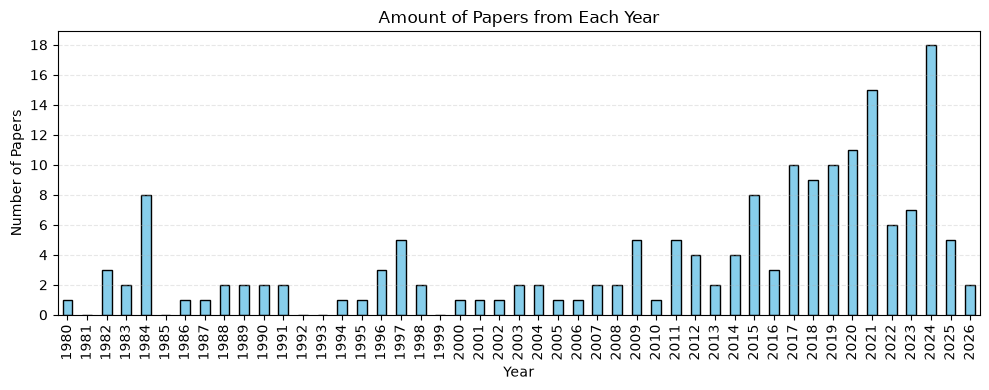

In [151]:
year_freq = df["Year"].value_counts().sort_index()

min_year = int(year_freq.index.min())
max_year = int(year_freq.index.max())
all_years = range(min_year, max_year + 1)
full_year_freq = year_freq.reindex(all_years, fill_value=0) # has years even with 0 papers

plt.figure(figsize=(10,4))

full_year_freq.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Amount of Papers from Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

#For a Trend Flow line. Right here:
#x_coords = np.arange(len(full_year_freq))
#plt.plot(x_coords, full_year_freq.values, color="red", alpha=0, marker="", linewidth=1, label="Trend Flow")

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Sets the y to be only ints
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()